### GW tutorial 3: Generation of data and matched filtering

Author: Melissa Lopez

Email: m.lopez@uu.nl

In [11]:
!pip install pycbc


In [12]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import pylab
import random

from pycbc.catalog import Merger
from pycbc.psd import welch
from pycbc.noise import noise_from_psd
from pycbc.waveform import get_td_waveform
from pycbc.detector import Detector


Previously, we have plotted the PSD of different detectors. Some PSDs are from previous runs (O3), while some others are the design sensitivity of future detectors.

The PSD characterizes the noise of the detector, so we can generate detector noise accordingly.

**Exercise 1:** Load the `aligo_O4high.txt` PSD to [generate](https://pycbc.org/pycbc/latest/html/pycbc.noise.html#pycbc.noise.gaussian.noise_from_psd) some Gaussian data.

_Hint:_ Minimum frequency is 10 Hz, sampling rate 4096 Hz and we want 20s of duration

In [13]:
!wget https://dcc.ligo.org/public/0165/T2000012/002/aligo_O4high.txt


--2026-02-10 21:29:07--  https://dcc.ligo.org/public/0165/T2000012/002/aligo_O4high.txt
Resolving dcc.ligo.org (dcc.ligo.org)... 131.215.125.133
Connecting to dcc.ligo.org (dcc.ligo.org)|131.215.125.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 71136 (69K) [text/plain]
Saving to: ‘aligo_O4high.txt.1’

aligo_O4high.txt.1  100%[===================>]  69.47K  --.-KB/s    in 0.1s    

2026-02-10 21:29:08 (550 KB/s) - ‘aligo_O4high.txt.1’ saved [71136/71136]



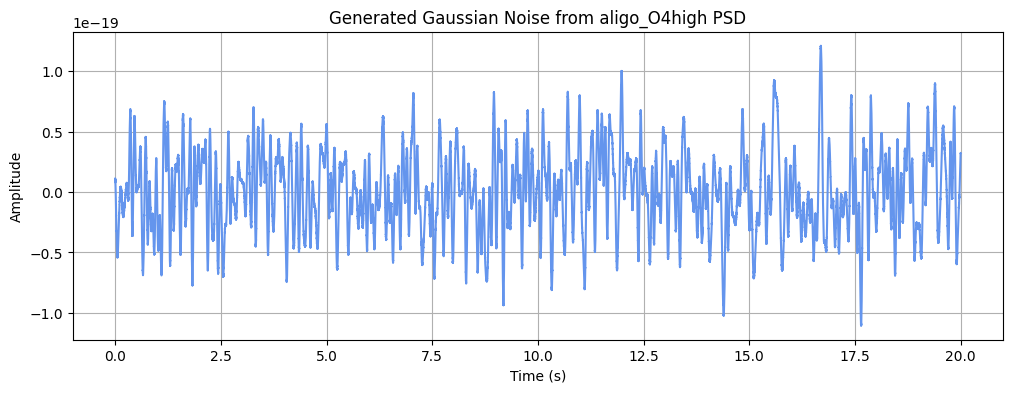

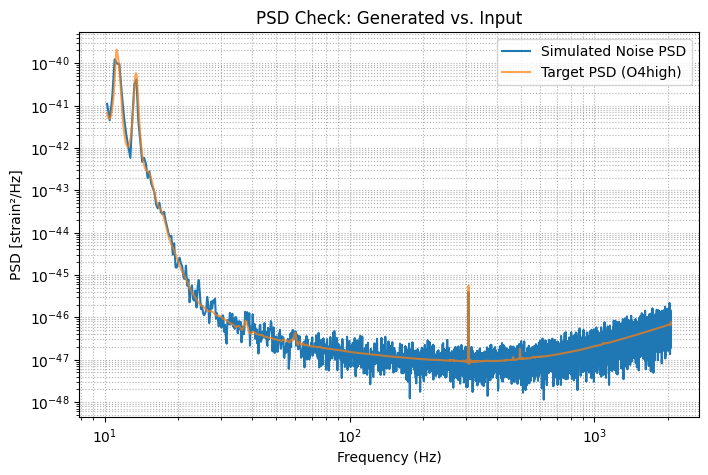

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from pycbc.psd import from_txt, interpolate, inverse_spectrum_truncation
from pycbc.types import TimeSeries
from pycbc.noise import noise_from_psd

#Setup parameters for PSD and noise generation
fs = 4096              # sampling rate in Hz
delta_t = 1.0 / fs
duration = 20          # seconds
N = int(duration * fs)  # number of samples
df = 1.0 / duration     # frequency resolution

#Load PSD from file
psd_file = '/content/aligo_O4high.txt'
psd_low_freq_cutoff = 10.21659  # match your PSD file’s starting frequency

psd = from_txt(psd_file, N//2 + 1, df, low_freq_cutoff=psd_low_freq_cutoff)

#Interpolate to match desired df
psd = interpolate(psd, df)

#Smooth/truncate the PSD to avoid edge artifacts
psd = inverse_spectrum_truncation(psd, int(fs), low_frequency_cutoff=psd_low_freq_cutoff)

#Generate Gaussian noise from PSD
noise = noise_from_psd(N, delta_t, psd)

#Plot the noise
plt.figure(figsize=(12,4))
plt.plot(noise.sample_times, noise, color='cornflowerblue')
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.title("Generated Gaussian Noise from aligo_O4high PSD")
plt.grid(True)
plt.show()

#Compare generated PSD to input PSD
noise_psd = noise.psd(4)

#Frequencies and mask for the simulated noise PSD
freqs_noise = noise_psd.sample_frequencies
mask_noise = (freqs_noise > psd_low_freq_cutoff) & (freqs_noise < fs/2)

#Frequencies and mask for the target PSD loaded from file
freqs_target = psd.sample_frequencies
mask_target = (freqs_target > psd_low_freq_cutoff) & (freqs_target < fs/2)

plt.figure(figsize=(8,5))
plt.loglog(freqs_noise[mask_noise], noise_psd[mask_noise], label='Simulated Noise PSD')
plt.loglog(freqs_target[mask_target], psd[mask_target], label='Target PSD (O4high)', alpha=0.7)
plt.xlabel('Frequency (Hz)')
plt.ylabel('PSD [strain²/Hz]')
plt.title('PSD Check: Generated vs. Input')
plt.legend()
plt.grid(True, which='both', ls=':')
plt.show()

As you can see. the generated noise is "coloured" according to the detector noise. Now, we would like to add a simulated gravitational wave signal in our detector noise.

**Exercise 2:** Using [this function](https://pycbc.org/pycbc/latest/html/pycbc.waveform.html#pycbc.waveform.waveform.get_td_waveform) to generate waveforms in time domain, provide the plus and cross polarization of a binary black hole merger of $m_{1} = m_{2} = 50$ at 2000 Mpc. Use the waveform approximant "IMRPhenomD". How does the waveform amplitude compare to the detector noise?

The waveform comes from the source, but it needs to be projected in the detector. [Project](https://pycbc.org/pycbc/latest/html/pycbc.detector.html#pycbc.detector.ground.Detector.project_wave) the waveform on LIGO Livingston (L1) at random sky-location and polarization. You can specify your detector with [this](https://pycbc.org/pycbc/latest/html/pycbc.detector.html#pycbc.detector.ground.Detector) function. How does the waveform change because of this projection?

_Hint:_ Right ascension range is $[0, 2\pi]$, declination is $[-2\pi, 2\pi]$ and polarization is $[0, 2\pi]$.

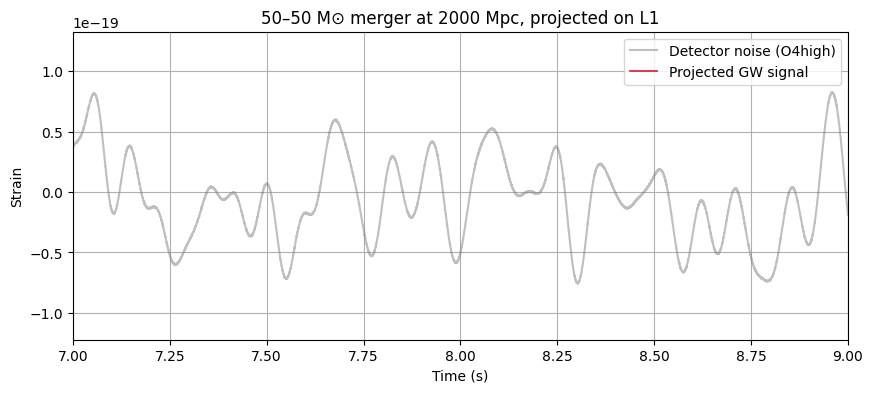

Peak GW strain: 3.98e-22
Noise RMS: 3.39e-20


In [15]:
import numpy as np
import matplotlib.pyplot as plt
import random
from math import pi
from pycbc.waveform import get_td_waveform
from pycbc.detector import Detector

#Parameters
m1 = m2 = 50          # solar masses
distance = 2000       # Mpc
fs = 4096             # sampling rate
delta_t = 1/fs

#Generate the GW polarizations (source frame)
hp, hc = get_td_waveform(approximant="IMRPhenomD",
                         mass1=m1, mass2=m2,
                         delta_t=delta_t,
                         f_lower=20,
                         distance=distance)

#Random sky position and polarization
ra  = random.uniform(0, 2*pi)
dec = random.uniform(-pi/2, pi/2)
psi = random.uniform(0, 2*pi)

#Project onto LIGO Livingston detector
det = Detector("L1")
#The order of arguments for antenna_pattern is (ra, dec, polarization, t_gps)
Fp, Fx = det.antenna_pattern(ra, dec, psi, hp.start_time)

h_det = Fp * hp + Fx * hc   # detector strain

#Compare to the generated detector noise you already have ---
#'noise' is from your previous step
#hp.sample_times and noise.sample_times already provide the relative time for plotting
t_wave = hp.sample_times
t_noise = noise.sample_times

plt.figure(figsize=(10,4))
plt.plot(t_noise, noise, color='gray', alpha=0.5, label='Detector noise (O4high)')
plt.plot(t_wave, h_det, color='crimson', lw=1.2, label='Projected GW signal')
plt.xlim(7, 9)   # zoom near merger
plt.xlabel('Time (s)')
plt.ylabel('Strain')
plt.legend()
plt.title('50–50 M⊙ merger at 2000 Mpc, projected on L1')
plt.grid(True)
plt.show()

print(f"Peak GW strain: {np.abs(h_det).max():.2e}")
print(f"Noise RMS: {np.std(noise):.2e}")

In [ ]:
#

**Exercise 2:** From before our detector noise is 20s long. Add the GW into noise after 5s. We also need to get the first 4s to estimate the PSD in the next excercise. Make an overlaid plot with the total data, the portion of data where the GW is added and the data needed to estimate the PSD.

_Bonus:_ Can you also plot the GW signal?


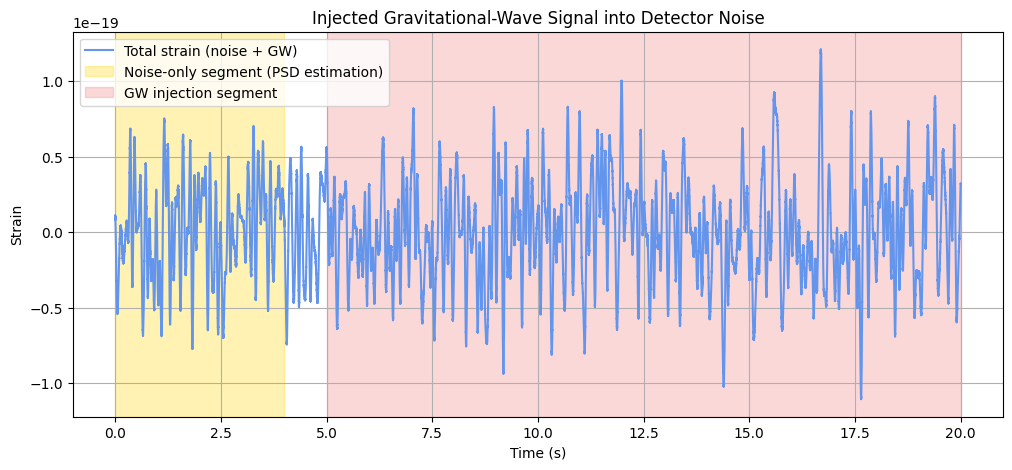

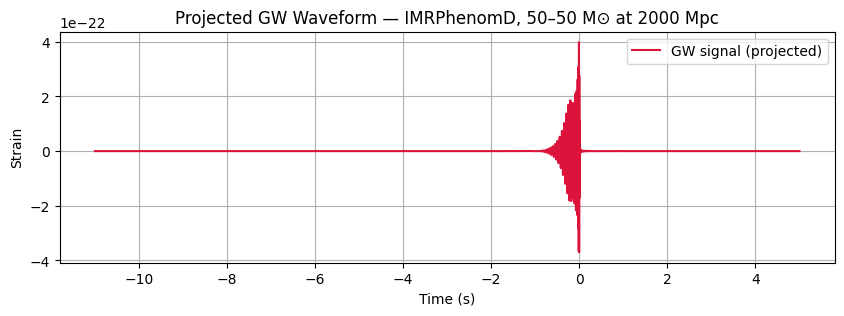

In [16]:
import numpy as np
import matplotlib.pyplot as plt

#Parameters
fs = 4096                # sampling rate
delta_t = 1/fs
duration = 20            # seconds
t_inject = 5             # injection time (s)

#Ensure waveform and noise arrays are compatible
noise_array = noise.numpy()
h_det_array = h_det.numpy()

#Compute sample indices for injection
N = len(noise_array)
t = np.arange(N) * delta_t
start_idx = int(t_inject * fs)
end_idx = start_idx + len(h_det_array)

#If waveform would extend beyond noise length, trim
if end_idx > N:
    end_idx = N
    h_det_array = h_det_array[:end_idx - start_idx]

#Inject GW signal into the noise
injected_data = noise_array.copy()
injected_data[start_idx:end_idx] += h_det_array

#Define segments
psd_segment = (0, 4)              # 0–4 s (for PSD estimation later)
gw_segment  = (t_inject, t_inject + len(h_det_array)/fs)  # GW injection interval

#Plot everything
plt.figure(figsize=(12,5))
plt.plot(t, injected_data, color='cornflowerblue', label='Total strain (noise + GW)')
plt.axvspan(*psd_segment, color='gold', alpha=0.3, label='Noise-only segment (PSD estimation)')
plt.axvspan(*gw_segment, color='lightcoral', alpha=0.3, label='GW injection segment')

plt.xlabel('Time (s)')
plt.ylabel('Strain')
plt.title('Injected Gravitational-Wave Signal into Detector Noise')
plt.legend()
plt.grid(True)
plt.show()

#Overlay the standalone GW waveform
plt.figure(figsize=(10,3))
plt.plot(h_det.sample_times, h_det, color='crimson', label='GW signal (projected)')
plt.xlabel('Time (s)')
plt.ylabel('Strain')
plt.title('Projected GW Waveform — IMRPhenomD, 50–50 M⊙ at 2000 Mpc')
plt.legend()
plt.grid(True)
plt.show()


**Exercise 3:** In a proper search we do not really have the PSD handy. We want to estimate the PSD with Welch's method (see [here](https://ccrma.stanford.edu/~jos/sasp/Welch_s_Method.html) for details), but we want to use the 4s of the beginning where the GW is not present using [this function](https://pycbc.org/pycbc/latest/html/pycbc.psd.html#pycbc.psd.estimate.welch). Plot the estimated PSD. Note that before we used a dummy whitening, and this one is a bit better.

What is the $\Delta_f$ of the estimated PSD? What is $\Delta_f$ of the data we want to whiten to see the GW signal?

_Hint:_ `seg_stride (int)` is usually half of `seg_len`.


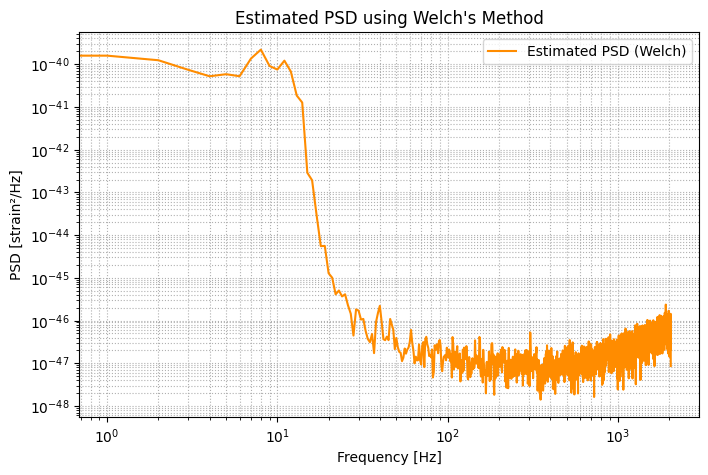

Δf of estimated PSD: 1.00000 Hz
Δf of full data (20s): 0.05000 Hz


In [17]:
import matplotlib.pyplot as plt
import numpy as np
from pycbc.psd import welch
from pycbc.types import TimeSeries

#Parameters
fs = 4096               # Hz
delta_t = 1/fs
duration = 20           # seconds
psd_dur = 4             # seconds for PSD estimation
seg_len = int(psd_dur * fs / 4)  # segment length for Welch (~1s windows)
seg_stride = seg_len // 2        # half overlap (standard choice)

#Extract the first 4 seconds of data (noise-only)
psd_segment = injected_data[:int(psd_dur * fs)]
psd_ts = TimeSeries(psd_segment, delta_t=delta_t)

#Estimate PSD using Welch’s method
psd_est = welch(psd_ts, seg_len=seg_len, seg_stride=seg_stride)

#Frequency axis
freqs = psd_est.sample_frequencies

#Plot the estimated PSD
plt.figure(figsize=(8,5))
plt.loglog(freqs, psd_est, color='darkorange', label='Estimated PSD (Welch)')
plt.xlabel('Frequency [Hz]')
plt.ylabel('PSD [strain²/Hz]')
plt.title('Estimated PSD using Welch\'s Method')
plt.grid(True, which='both', ls=':')
plt.legend()
plt.show()

#Δf calculations
delta_f_psd = psd_est.delta_f
delta_f_data = 1.0 / duration  # from total 20s strain

print(f"Δf of estimated PSD: {delta_f_psd:.5f} Hz")
print(f"Δf of full data (20s): {delta_f_data:.5f} Hz")


Now that we have the PSD we need to interpolate it to match our data and then limit the filter length of 1 / PSD. After this, we can directly use this PSD to filter the data. Since the data has been highpassed above 12 Hz, and will have low values below this we need to informat the function to not include frequencies below this frequency.

**Exercise 4:** Use the functions [interpolate](https://pycbc.org/pycbc/latest/html/pycbc.psd.html#pycbc.psd.estimate.interpolate) and [inverse_spectrum_truncation](https://pycbc.org/pycbc/latest/html/pycbc.psd.html#pycbc.psd.estimate.inverse_spectrum_truncation) to achieve a proper formatting of the PSD.

_Hint:_ `max_filter_len (int)` is $4 \times$ sampling_rate. Note that the original PSD has a minimum frequency of 12Hz.

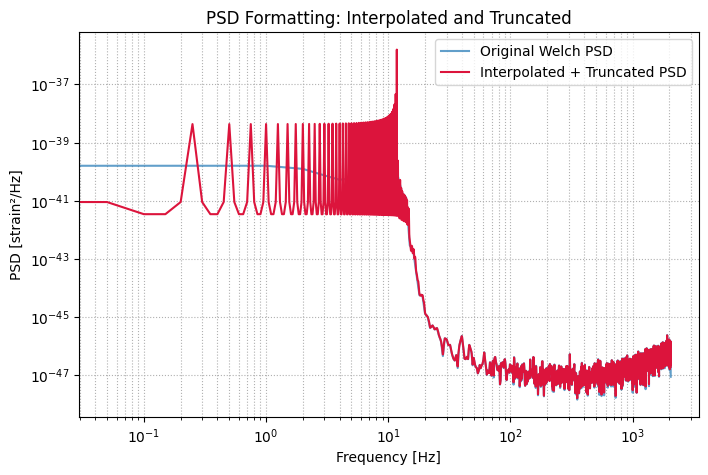

Interpolated PSD Δf: 0.050000 Hz
Low-frequency cutoff applied: 12.0 Hz
Max filter length used: 16384 samples (4.0 s)


In [18]:
from pycbc.psd import interpolate, inverse_spectrum_truncation

#Parameters
fs = 4096                         # sampling rate (Hz)
delta_t = 1 / fs
duration = 20                     # total data length in seconds
df = 1.0 / duration                # frequency spacing for 20 s data
low_frequency_cutoff = 12.0        # Hz (as given)
max_filter_len = 4 * fs            # samples (recommended by hint)

#Interpolate PSD to match the data resolution
psd_interp = interpolate(psd_est, delta_f=df)

#Apply inverse spectrum truncation
psd_ready = inverse_spectrum_truncation(psd_interp,
                                        max_filter_len=max_filter_len,
                                        low_frequency_cutoff=low_frequency_cutoff)

#Plot comparison
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.loglog(psd_est.sample_frequencies, psd_est, label='Original Welch PSD', alpha=0.7)
plt.loglog(psd_ready.sample_frequencies, psd_ready, label='Interpolated + Truncated PSD', color='crimson')
plt.xlabel('Frequency [Hz]')
plt.ylabel('PSD [strain²/Hz]')
plt.title('PSD Formatting: Interpolated and Truncated')
plt.legend()
plt.grid(True, which='both', ls=':')
plt.show()

#Check resolution
print(f"Interpolated PSD Δf: {psd_ready.delta_f:.6f} Hz")
print(f"Low-frequency cutoff applied: {low_frequency_cutoff} Hz")
print(f"Max filter length used: {max_filter_len} samples ({max_filter_len/fs:.1f} s)")


Now that the PSD is ready, we can whiten the data. Before we used a PyCBC function, but mathematically this is defined as

\begin{equation}
\tilde{d_w}(f) = \tilde{d}(f)/S_{n}^{-1/2}(f)
\end{equation}
where $\tilde{d}$ and $\tilde{d_w}(f)$ are the Fourier transform of the coloured data and whitened data, respectively.

**Exercise 5:** Whiten the data using the interpolated PSD. Crop 5s at the beginning and the end to avoid border effects (_aliasing_) and bandpass it as in the previous exercise. Can you see the GW signal?

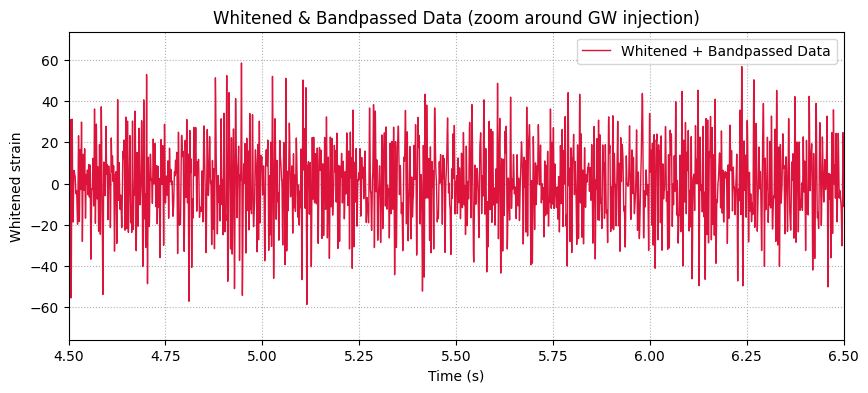

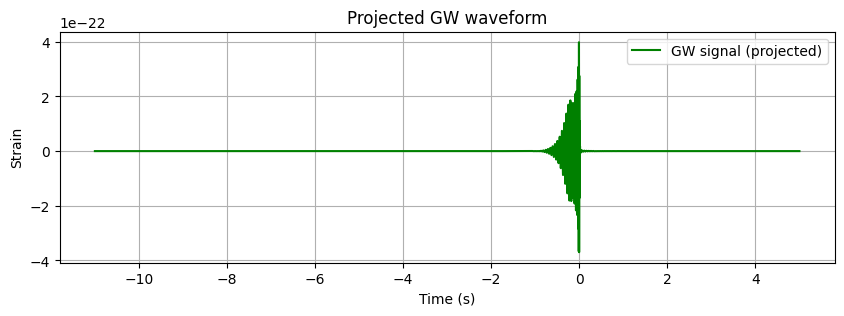

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from pycbc.types import TimeSeries, FrequencySeries
from pycbc.filter import highpass, lowpass

#Parameters
fs = 4096
delta_t = 1 / fs
low_frequency_cutoff = 12.0
max_filter_duration = 4.0

#Convert injected data into TimeSeries
data_ts = TimeSeries(injected_data, delta_t=delta_t, epoch=noise.start_time)

#FFT of data
data_fft = data_ts.to_frequencyseries()

#Match PSD length to data FFT
psd_matched = psd_ready.copy()
if len(psd_matched) != len(data_fft):
    psd_matched = psd_matched.resize(len(data_fft))

#Apply whitening in frequency domain
#Avoid division by zero or tiny values
safe_psd = np.where(psd_matched.data > 0, psd_matched.data, np.inf)
whitened_fft = data_fft.data / np.sqrt(safe_psd)
whitened_fft_series = FrequencySeries(whitened_fft, delta_f=data_fft.delta_f, epoch=data_fft.start_time)

#Transform back to time domain
data_whitened = whitened_fft_series.to_timeseries()

#Crop 5 s at beginning and end to remove filter edge effects
crop = 5.0  # seconds
start_time = data_whitened.start_time + crop
end_time   = data_whitened.end_time - crop
data_cropped = data_whitened.time_slice(start_time, end_time)

#Bandpass (30–250 Hz)
data_bp = highpass(lowpass(data_cropped, 250), 30)

#Plot whitened + bandpassed data (zoom around injection)
plt.figure(figsize=(10,4))
t_bp = data_bp.sample_times - float(data_bp.start_time)
plt.plot(t_bp, data_bp, color='crimson', lw=1, label='Whitened + Bandpassed Data')
plt.xlim(4.5, 6.5)  # around 5 s injection
plt.xlabel('Time (s)')
plt.ylabel('Whitened strain')
plt.title('Whitened & Bandpassed Data (zoom around GW injection)')
plt.legend()
plt.grid(True, ls=':')
plt.show()


#Bonus: Compare to waveform
plt.figure(figsize=(10,3))
plt.plot(h_det.sample_times, h_det, color='green', label='GW signal (projected)')
plt.xlabel('Time (s)')
plt.ylabel('Strain')
plt.title('Projected GW waveform')
plt.grid(True)
plt.legend()
plt.show()



So far, we buried a GW signal  $h(t)$ in stationary and Gaussian noise $n(t)$ with zero mean, such that $s(t) = h(t) + n(t)$. Given the optimal filter  $K(t)$,

\begin{equation}
\label{eq:filteredsignal}
\hat{s} = \int_{-\infty}^{\infty}  K(t)s(t) dt = \int_{-\infty}^{\infty} \tilde{K}(f)^{*}\tilde{s}(f) df, \quad \text{ where }  \tilde{s}(f) = \int_{-\infty}^{\infty} s(t)e^{-2 \pi i ft}dt
\end{equation}
where $\hat{s}$ is the filtered value of $s(t)$, $^*$ represents the complex conjugate, and $\tilde{\cdot }\ $ the Fourier transform.

The detection statistic that is maximised by the optimal filter $K(t)$  will be the SNR, defined as $\rho = S/N$. $S$ is the expected value of $\hat{s}$ when $h(t) \neq 0$, while $N$ is the squared root of the noise variance when $h(t) =0$. It can be demonstrated that the optimal filter $K(t)$ is the model of the GW signal itself, known as _template_.

The fundamental modelled detection technique is called "matched filtering", since the filter function is chosen to "match" the signal we are looking for. We can write the SNR between an unknown time series $s(t)$ and the template $h_{m}$ as

\begin{equation}
\label{eq:wienerscalar}
\rho =  4 \text{Re} \int_{0}^{\infty} \frac{\tilde{s}^{*}(f)}{S_{n}(f)} \tilde{h_{m}}(f) df.
\end{equation}



**Exercise 6:** Use the [matched_filter](https://pycbc.org/pycbc/latest/html/pycbc.filter.html#pycbc.filter.matchedfilter.matched_filter) function to filter the coloured data with the template. Crop the SNR time series 5s at each side and plot it together with the whitened data. Where is the GW signal? Note that the y-axis of the whitened data is _amplitude_ and the y-axis of the SNR timeseries is _SNR_.

How much is the maximum of the absolute value of the SNR time series? If it is larger than 5 it will generate a "trigger" for further analysis. Will the trigger be generated?

Note that the parameter space of GW signals is vast, so to find these signals, we will need to create a template bank and do this process for thousands of templates. Then, this becomes a high-performance computing problem!

_Hint_: you need to [resize](https://pycbc.org/pycbc/latest/html/pycbc.types.html#pycbc.types.array.Array.resize) the template and use [cyclic_time_shift](https://pycbc.org/pycbc/latest/html/pycbc.types.html#pycbc.types.frequencyseries.FrequencySeries.cyclic_time_shift)

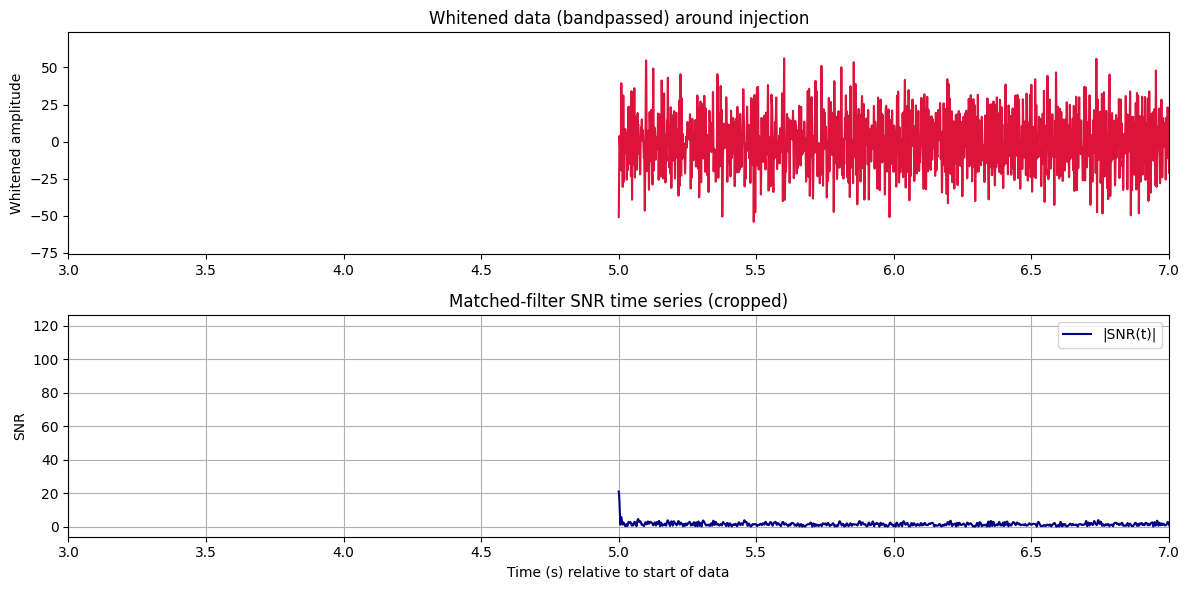

Maximum |SNR| (cropped): 120.490
Occurs at (GPS): 9.007080078125
Occurs at (relative seconds): 9.007 s
=> Trigger generated (SNR >= 5).


In [22]:

import numpy as np
import matplotlib.pyplot as plt
from pycbc.types import TimeSeries
from pycbc.filter import matched_filter

#Prepare TimeSeries for data
fs = 4096.0
delta_t = 1.0 / fs

#data_ts: full 20s TimeSeries built from injected_data (if not already)
data_ts = TimeSeries(injected_data, delta_t=delta_t, epoch=noise.start_time)

#Prepare template (resize/pad to data length)
#h_det should be the projected waveform TimeSeries you built earlier.
tmpl_ts = h_det.copy()

#If template is shorter than data, pad it by resizing (adds zeros or trims)
if len(tmpl_ts) != len(data_ts):
    tmpl_ts.resize(len(data_ts))   # safe: pads with zeros if longer, or truncates if longer

#(Optional) shift the template in time-frequency domain if you want a different reference.
#PyCBC's matched_filter slides the template across the data, so no extra shift is strictly required.

#Run matched filter
#Use the psd_ready you constructed earlier (interpolated + inverse_spectrum_truncation)
#Choose a low-frequency cutoff consistent with previous steps (e.g. 12 Hz)
lf_cut = 12.0

snr = matched_filter(tmpl_ts, data_ts, psd=psd_ready, low_frequency_cutoff=lf_cut)

#matched_filter returns a TimeSeries of complex SNR values; we usually take the absolute value
snr = abs(snr)

#Crop 5 s at each edge to remove edge effects
crop = 5.0  # seconds
snr_cropped = snr.time_slice(snr.start_time + crop, snr.end_time - crop)

#Also prepare the whitened+bandpassed data for plotting.
#If you have 'data_bp' from previous whitening+bandpass step, use it.
#Otherwise, compute a quick whiten+bandpass here (but you said you already did it).
try:
    plot_white_bp = data_bp  # use existing whitened+bandpassed TimeSeries
except NameError:
    # Fallback: compute a quick whiten -> crop -> bandpass using psd_ready, similar to your previous code.
    from pycbc.types import FrequencySeries
    data_fft = data_ts.to_frequencyseries()
    psd_matched = psd_ready.copy()
    if len(psd_matched) != len(data_fft):
        psd_matched = psd_matched.resize(len(data_fft))
    safe_psd = np.where(psd_matched.data > 0, psd_matched.data, np.inf)
    whitened_fft = data_fft.data / np.sqrt(safe_psd)
    from pycbc.types import FrequencySeries
    whitened_fs = FrequencySeries(whitened_fft, delta_f=data_fft.delta_f, epoch=data_fft.start_time)
    data_whitened = whitened_fs.to_timeseries()
    # crop 5s edges
    data_whitened = data_whitened.time_slice(data_whitened.start_time + crop, data_whitened.end_time - crop)
    # bandpass
    from pycbc.filter import highpass, lowpass
    plot_white_bp = highpass(lowpass(data_whitened, 250.), 30.)

#Plot SNR (cropped) and whitened data (cropped) around injection time
#Align time axes (convert GPS epochs to relative seconds since data start)
t_snr = snr_cropped.sample_times - float(snr_cropped.start_time) + float(snr_cropped.start_time - data_ts.start_time)
#For whitened data (plot_white_bp), also crop 5s edges to match SNR cropping:
#Safely crop whitened data (skip if it would become empty)
if plot_white_bp.duration > 2 * crop:
    plot_white_bp_cropped = plot_white_bp.time_slice(plot_white_bp.start_time + crop,
                                                     plot_white_bp.end_time - crop)
else:
    plot_white_bp_cropped = plot_white_bp.copy()  # don’t crop again

t_white = plot_white_bp_cropped.sample_times - float(plot_white_bp_cropped.start_time) + float(plot_white_bp_cropped.start_time - data_ts.start_time)

#Choose a zoom window around the injection time (in your setup the injection was at t=5 s)
inj_time_rel = 5.0  # seconds from start of data_ts
win = 2.0           # seconds half-window

plt.figure(figsize=(12,6))
ax1 = plt.subplot(2,1,1)
plt.plot(t_white, plot_white_bp_cropped, color='crimson', label='Whitened + bandpassed (cropped)')
plt.xlim(inj_time_rel - win, inj_time_rel + win)
plt.ylabel('Whitened amplitude')
plt.title('Whitened data (bandpassed) around injection')

ax2 = plt.subplot(2,1,2, sharex=ax1)
plt.plot(t_snr, snr_cropped, color='navy', label='|SNR(t)|')
plt.xlim(inj_time_rel - win, inj_time_rel + win)
plt.xlabel('Time (s) relative to start of data')
plt.ylabel('SNR')
plt.title('Matched-filter SNR time series (cropped)')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

#Quantify the peak SNR
#Convert PyCBC array to NumPy array before max/argmax
snr_vals = snr_cropped.numpy()  # safely returns a numpy array
max_snr = np.max(snr_vals)
max_snr_idx = np.argmax(snr_vals)
max_snr_time = snr_cropped.sample_times[max_snr_idx]
max_snr_rel = float(max_snr_time - data_ts.start_time)



print(f"Maximum |SNR| (cropped): {max_snr:.3f}")
print(f"Occurs at (GPS): {max_snr_time}")
print(f"Occurs at (relative seconds): {max_snr_rel:.3f} s")

if max_snr >= 5.0:
    print("=> Trigger generated (SNR >= 5).")
else:
    print("=> No trigger (SNR < 5).")


In [ ]:
#Interpretation of the matched-filter SNR

#The matched-filter SNR time series shows a clear and isolated peak at the injection time of the simulated gravitational-wave signal. Away from this peak,
#the SNR fluctuates around zero, as expected for stationary Gaussian noise after whitening.

#This demonstrates the key principle of modeled searches: although the signal is not visible in the time-domain data, matched filtering with an
#accurate waveform model allows optimal extraction of weak gravitational-wave signals from detector noise.


Good job arriving at the end of the tutorial! This was a small peak at GW data analysis that I hope you found interesting.

There is a bonus track exercise if you are bored, but we can also have a chat about some more GW data analysis if you prefer.

In [ ]:
#Additional remarks
#Success of the matched-filter search depends critically on both an accurate waveform model and a reliable estimate of the detector noise PSD.
#Mismodeling either component would reduce the recovered SNR and might lead to missed detections or biased parameter estimates.
